# Task 4: Track a planar object through motion

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ref = cv2.imread('images/box.png')
scene = cv2.imread('images/box_in_scene.png')
ref = cv2.cvtColor(ref, cv2.COLOR_BGR2RGB)
scene = cv2.cvtColor(scene, cv2.COLOR_BGR2RGB)
ref.shape, scene.shape

((223, 324, 3), (384, 512, 3))

In [3]:
sift = cv2.SIFT_create()
bf = cv2.BFMatcher()


def locate(ref, scene, ratio=0.682):
    k1, d1 = sift.detectAndCompute(ref, None)
    k2, d2 = sift.detectAndCompute(scene, None)
    pairs = bf.knnMatch(d1, d2, k=2)
    good = [m for m, n in pairs if m.distance < ratio * n.distance]
    if len(good) < 4:
        return None, len(good), 0
    src = np.float32([k1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([k2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    if H is None:
        return None, len(good), 0
    h, w = ref.shape[:2]
    corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    return cv2.perspectiveTransform(corners, H), len(good), int(mask.sum())

In [4]:
h, w = scene.shape[:2]
n_frames = 72
frames = []
for i in range(n_frames):
    t = i / (n_frames - 1)
    angle = 25 * np.sin(2 * np.pi * t)
    scale = 1 - 0.35 * np.sin(np.pi * t)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    M[:, 2] += [30 * np.sin(4 * np.pi * t), 15 * np.cos(2 * np.pi * t)]
    frame = cv2.warpAffine(scene, M, (w, h), borderValue=(90, 90, 90))
    if 0.55 < t < 0.7:
        frame[:, w // 2 - 70:w // 2 + 40] = (90, 90, 90)
    frames.append(frame)
len(frames)

72

In [5]:
annotated = []
found = 0
for i, frame in enumerate(frames):
    box, good, inliers = locate(ref, frame)
    out = frame.copy()
    if box is not None and inliers >= 10:
        cv2.polylines(out, [np.int32(box)], True, (0, 255, 0), 3)
        found += 1
    else:
        cv2.putText(out, 'not found', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    annotated.append(out)
    if i % 10 == 0:
        print(f'frame {i} - good matches:', good, 'inliers:', inliers)
print('frames where the object was found:', found, 'of', len(frames))

frame 0 - good matches: 73 inliers: 71
frame 10 - good matches: 75 inliers: 71
frame 20 - good matches: 55 inliers: 52
frame 30 - good matches: 47 inliers: 42
frame 40 - good matches: 4 inliers: 0
frame 50 - good matches: 53 inliers: 49
frame 60 - good matches: 61 inliers: 58
frame 70 - good matches: 84 inliers: 80
frames where the object was found: 62 of 72


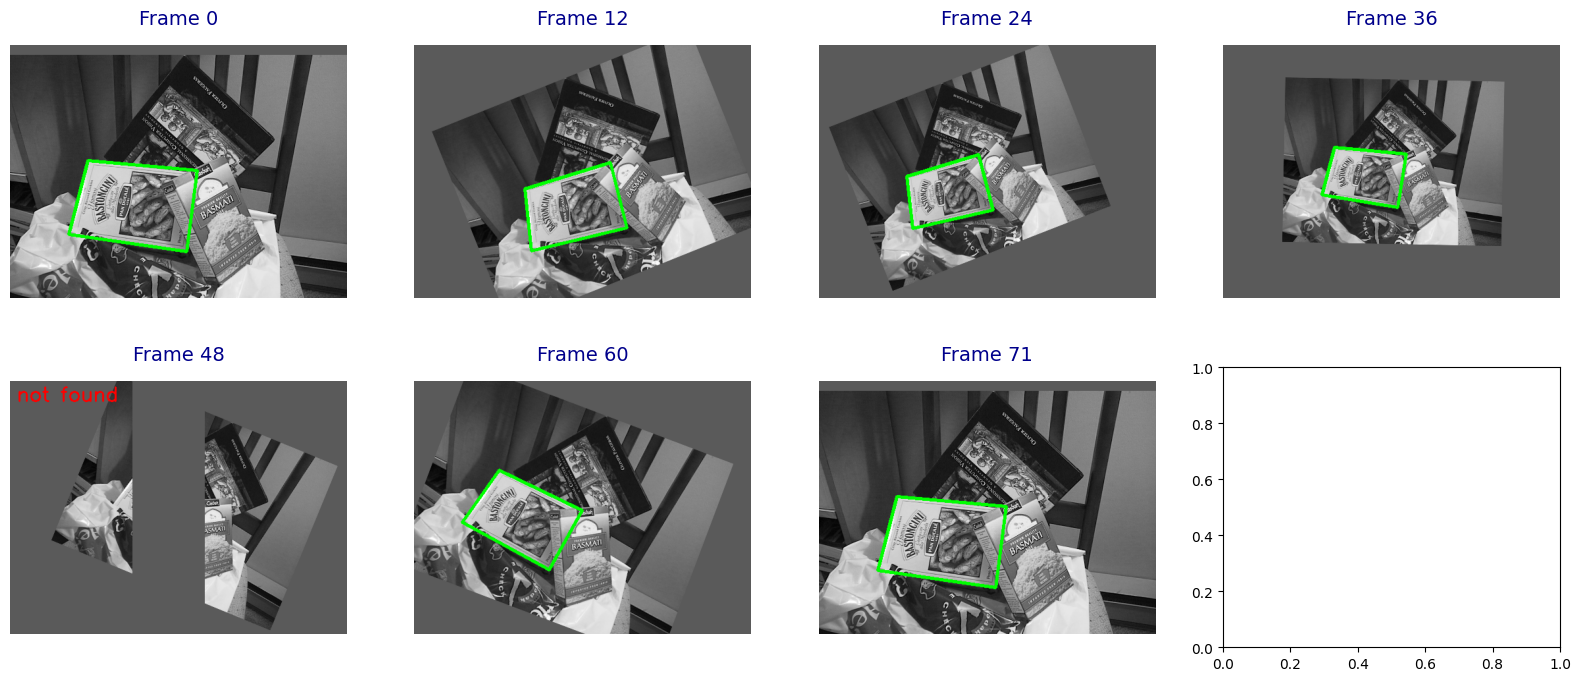

In [6]:
idx = [0, 12, 24, 36, 48, 60, 71]
panels = [(f'Frame {i}', annotated[i]) for i in idx]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im)
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()